In [1]:
import os
import re
import sys
import glob
import time
import yaml
import intake
import warnings
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from collections import defaultdict
from xarray.coding.times import CFDatetimeCoder

warnings.filterwarnings("ignore") # Suppress warnings for these docs
time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/34767/status,
Dashboard: /proxy/34767/status,Workers: 4
Total threads: 12,Total memory: 46.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42229,Workers: 0
Dashboard: /proxy/34767/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40227,Total threads: 3
Dashboard: /proxy/42427/status,Memory: 11.50 GiB
Nanny: tcp://127.0.0.1:41509,


In [3]:
print('Starting ACCESS-OM2 and SOTS latent heat flux analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri
#print(catalog.keys())

#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2 
#----------------------------------------------------------------------------------------------

var   =  'evap_heat'

experiments = ['1deg_jra55_iaf_omip2_cycle6', '025deg_jra55_iaf_omip2_cycle6', ['01deg_jra55v140_iaf_cycle4', '01deg_jra55v140_iaf_cycle4_jra55v150_extension']]

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

var_SOTS   =  'HL'

#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]


Starting ACCESS-OM2 and SOTS latent heat flux analysis.


In [4]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")
    



Processing ACCESS evap_heat data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [5]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    exp_heat_flux[exp] = {
        "heat_flux": heat_flux}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()


Start collecting evap_heat 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.04 minutes
Start collecting evap_heat 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.04 minutes
Start collecting evap_heat 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting evap_heat data for ACCESS.
Execution time: 0.10 minutes


In [6]:
#----------------------------------------------------------------------------------------------
# Read and collect data for SOTS
#----------------------------------------------------------------------------------------------

print(f'Processing SOTS {var} data...')
sys.stdout.flush()


SOTS_dir  = '/g/data/jk72/mxr581/SOTS-project-data/sots/flux'
SOTS_pattern = os.path.join(SOTS_dir, "IMOS_DWM-*_CFMST_20*.nc")

SOTS_paths = glob.glob(SOTS_pattern)

def extract_year(path):
    match = re.search(r'CFMST_(\d{4})', path)
    if match:
        return int(match.group(1))
  
SOTS_sorted = sorted(SOTS_paths, key=extract_year)

start = time.time()

ds = xr.open_mfdataset(
    SOTS_sorted,
    combine='nested',
    concat_dim='TIME',
    data_vars='minimal',
    coords='minimal',
    compat='override'# need this as position of buoy moves around
)[[var_SOTS]]

SOTS_flux = ds[var_SOTS]

ds.close()

end = time.time()  

print(f'Finished collecting {var} data.')
sys.stdout.flush()

print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing SOTS evap_heat data...
Finished collecting evap_heat data.
Execution time: 0.46 minutes


Processing 1deg_jra55_iaf_omip2_cycle6 ...
Done 1deg_jra55_iaf_omip2_cycle6
Processing 025deg_jra55_iaf_omip2_cycle6 ...
Done 025deg_jra55_iaf_omip2_cycle6
Processing 01deg_jra55v140_iaf_cycle4 ...
Done 01deg_jra55v140_iaf_cycle4


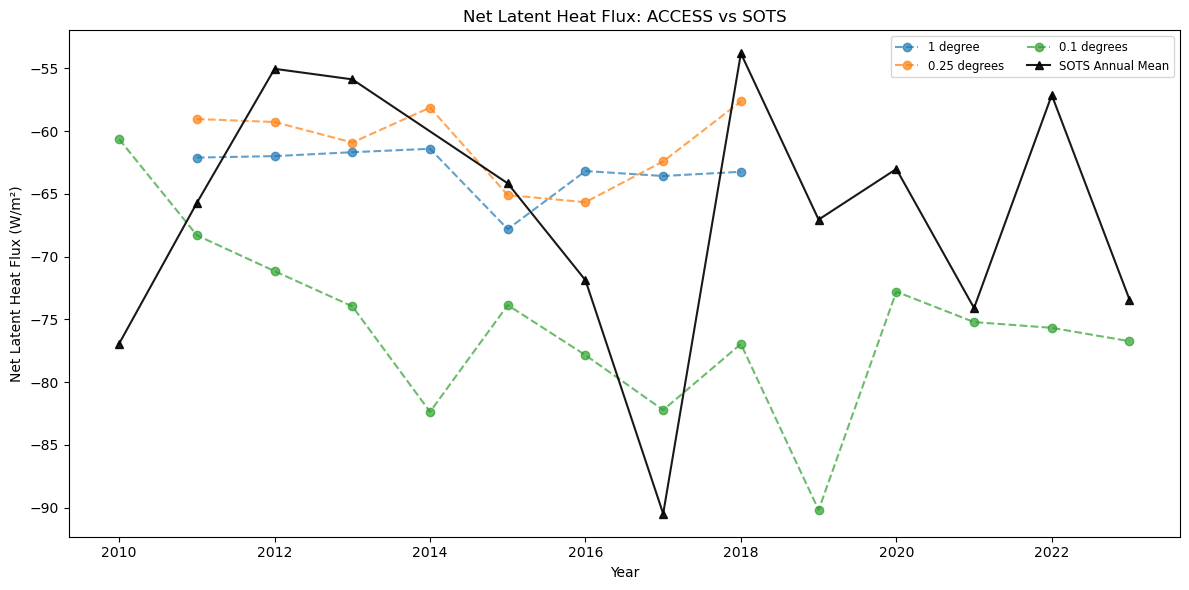

In [8]:
#----------------------------------------------------------------------------------------------
# PLOT
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12,6))

exp_titles = {
    '1deg_jra55_iaf_omip2_cycle6': '1 degree',
    '025deg_jra55_iaf_omip2_cycle6': '0.25 degrees',
    '01deg_jra55v140_iaf_cycle4': '0.1 degrees'
}


for exp_name, data_dict in exp_heat_flux.items():
    print(f"Processing {exp_name} ...")
    heat_flux = data_dict['heat_flux']

    annual_exp = heat_flux.groupby('time.year').mean(dim='time')
    annual_exp_np = annual_exp.compute()
    years = annual_exp['year'].values  

    # titles
    label = exp_titles.get(exp_name, exp_name)
    
    ax.plot(years, annual_exp_np,
            marker='o', linestyle='--', alpha=0.7, label=label)
    print(f"Done {exp_name}")


# SOTS comparison
annual_SOTS = SOTS_flux.groupby('TIME.year').mean(dim='TIME').compute()
ax.plot(annual_SOTS['year'].values, -1*annual_SOTS.values,
        color='black', marker='^', linestyle='-', alpha=0.9, label='SOTS Annual Mean')


ax.set_xlabel('Year')
ax.set_ylabel('Net Latent Heat Flux (W/m²)')
ax.set_title('Net Latent Heat Flux: ACCESS vs SOTS')
ax.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()